# Customer Lifetime Value Predictor
### Predicting 90-day revenue per customer from 1M+ retail transactions
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](PASTE_YOUR_LINK)
![Python](https://img.shields.io/badge/Python-3.10-blue)
![XGBoost](https://img.shields.io/badge/Model-XGBoost-orange)
![SHAP](https://img.shields.io/badge/Explainability-SHAP-green)
[![Dataset](https://img.shields.io/badge/Dataset-UCI%20Online%20Retail%20II-green)](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II)

---
**Objective:** Build a regression model that predicts each customer's
next 90-day revenue using RFM + behavioural features from the UCI
Online Retail II dataset, and segment customers into High / Mid / Low
CLV tiers to enable targeted marketing spend.

**Dataset:** UCI Online Retail II — 1,067,371 transactions,
4,312 customers, UK e-commerce (2009–2011)

#Imports & config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mticker
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 20)

RANDOM_SEED   = 42
OUTLIER_ZSCORE = 3.5          # rows beyond this z-score on TotalPrice are outliers
MIN_ORDERS     = 2            # keep only customers with >= 2 valid orders
SNAPSHOT_OFFSET = 1           # days to add to max date for RFM recency calc

#Data loading


In [2]:
URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
)

df_09 = pd.read_excel(URL, sheet_name="Year 2009-2010", engine="openpyxl")
df_10 = pd.read_excel(URL, sheet_name="Year 2010-2011", engine="openpyxl")
df_raw = pd.concat([df_09, df_10], ignore_index=True)

print(f"Raw dataset : {df_raw.shape[0]:>10,} rows  |  {df_raw.shape[1]} columns")
print(df_raw.dtypes)
print(df_raw.head(3))

Raw dataset :  1,067,371 rows  |  8 columns
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95     13085.00  United Kingdom  
1 2009-12-01 07:45:00   6.75     13085.00  United Kingdom  
2 2009-12-01 07:45:00   6.75     13085.00  United Kingdom  


###Data wrangling

In [3]:
def audit(df, label=""):
    n_rows      = len(df)
    n_customers = df["Customer ID"].nunique()
    null_cust   = df["Customer ID"].isna().sum()
    cancelled   = df["Invoice"].astype(str).str.startswith("C").sum()
    neg_qty     = (df["Quantity"] < 0).sum()
    neg_price   = (df["Price"] <= 0).sum()
    print(
        f"\n{'─'*50}\n"
        f"  Audit : {label}\n"
        f"{'─'*50}\n"
        f"  Rows             : {n_rows:>10,}\n"
        f"  Unique customers : {n_customers:>10,}\n"
        f"  Null Customer ID : {null_cust:>10,}  ({null_cust/n_rows:.1%})\n"
        f"  Cancelled rows   : {cancelled:>10,}  ({cancelled/n_rows:.1%})\n"
        f"  Negative qty     : {neg_qty:>10,}\n"
        f"  Zero/neg price   : {neg_price:>10,}\n"
    )

audit(df_raw, "BEFORE CLEANING")


──────────────────────────────────────────────────
  Audit : BEFORE CLEANING
──────────────────────────────────────────────────
  Rows             :  1,067,371
  Unique customers :      5,942
  Null Customer ID :    243,007  (22.8%)
  Cancelled rows   :     19,494  (1.8%)
  Negative qty     :     22,950
  Zero/neg price   :      6,207



In [4]:
# Drop null Customer IDs
before = len(df_raw)
df = df_raw.dropna(subset=["Customer ID"]).copy()
after  = len(df)

print(f"Dropped {before - after:,} rows with null Customer ID  "
      f"({(before - after)/before:.1%} of raw data)")

# Ensure Customer ID is integer
df["Customer ID"] = df["Customer ID"].astype(int)

Dropped 243,007 rows with null Customer ID  (22.8% of raw data)


In [5]:
#Invoices starting with 'C' are cancellations (returns).
# Strategy: remove both the original and the cancellation row
# so net revenue is correctly computed. Where we cannot find a
# matching original, we still remove the cancellation.

df["is_cancelled"] = df["Invoice"].astype(str).str.startswith("C")

cancelled_df = df[df["is_cancelled"]].copy()
normal_df = df[ ~ df["is_cancelled"]].copy()

print(f"Cancelled rows     : {len(cancelled_df):,}")
print(f"Normal order rows  : {len(normal_df):,}")

cancelled_keys = set(
    zip(
        cancelled_df["Customer ID"],
        cancelled_df["StockCode"],
    )
)

mask_has_return = normal_df.apply(
    lambda r: (r["Customer ID"], r["StockCode"]) in cancelled_keys, axis=1
)

print(f"\nOriginal rows matched to a cancellation : {mask_has_return.sum():,}")

# Keep normal rows that were NOT cancelled
df = normal_df[~mask_has_return].copy()
df = df.drop(columns=["is_cancelled"])

print(f"Rows after cancellation handling : {len(df):,}")


Cancelled rows     : 18,744
Normal order rows  : 805,620

Original rows matched to a cancellation : 46,227
Rows after cancellation handling : 759,393


In [6]:
# concider rows only with 5-digit integral number uniquely
df = df[df['StockCode'].astype(str).str.match(r'^\d{5}$')]
print(f"Rows with only with 5-digit integral number : {len(df):,}")

#Date parsing and validation
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(f"Date range : {df['InvoiceDate'].min().date()}  →  {df['InvoiceDate'].max().date()}")
print(f"Span       : {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

Rows with only with 5-digit integral number : 673,765
Date range : 2009-12-01  →  2011-12-09
Span       : 738 days


In [7]:
# check for outliers
df["TotalPrice"] = df["Quantity"] * df["Price"]
print(f"Mean   : £{df['TotalPrice'].mean():.2f}")
print(f"Median : £{df['TotalPrice'].median():.2f}")
print(f"Ratio  : {df['TotalPrice'].mean() / df['TotalPrice'].median():.1f}x")

print("\n--- Percentiles (this is where outliers hide) ---")
for p in [50, 75, 90, 95, 99, 99.5, 100]:
    val = df['TotalPrice'].quantile(p/100)
    print(f"  {p:>5.1f}th percentile : £{val:>10,.2f}")

print(f"\nMax value   : £{df['TotalPrice'].max():>10,.2f}")

Mean   : £19.57
Median : £11.25
Ratio  : 1.7x

--- Percentiles (this is where outliers hide) ---
   50.0th percentile : £     11.25
   75.0th percentile : £     17.85
   90.0th percentile : £     33.00
   95.0th percentile : £     59.40
   99.0th percentile : £    174.00
   99.5th percentile : £    254.40
  100.0th percentile : £  7,144.72

Max value   : £  7,144.72


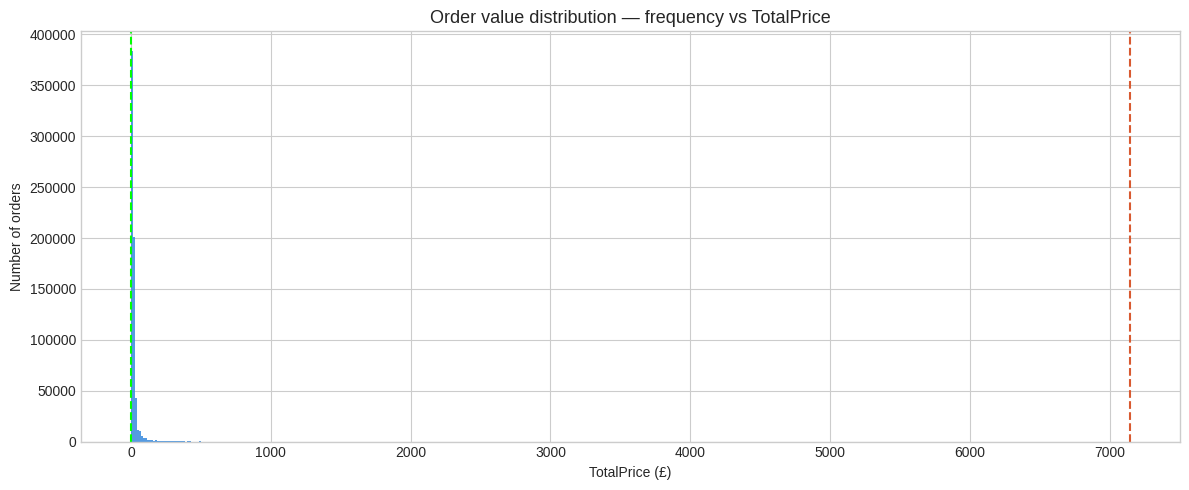

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["TotalPrice"], bins=500, color="#378ADD", edgecolor="none", alpha=0.85)

ax.set_title("Order value distribution — frequency vs TotalPrice", fontsize=13)
ax.set_xlabel("TotalPrice (£)")
ax.set_ylabel("Number of orders")

# max value - outlier
max_val = df["TotalPrice"].max()
ax.axvline(max_val, color="#D85A30", linewidth=1.5, linestyle="--")
# min value
min_val = df["TotalPrice"].min()
ax.axvline(min_val, color="#00FF00", linewidth=1.5, linestyle="--")

plt.tight_layout()
plt.show()

**It clear that the data is right skewed**

Outlier rows (|z| > 3.5) : 2,140  (0.32%) 



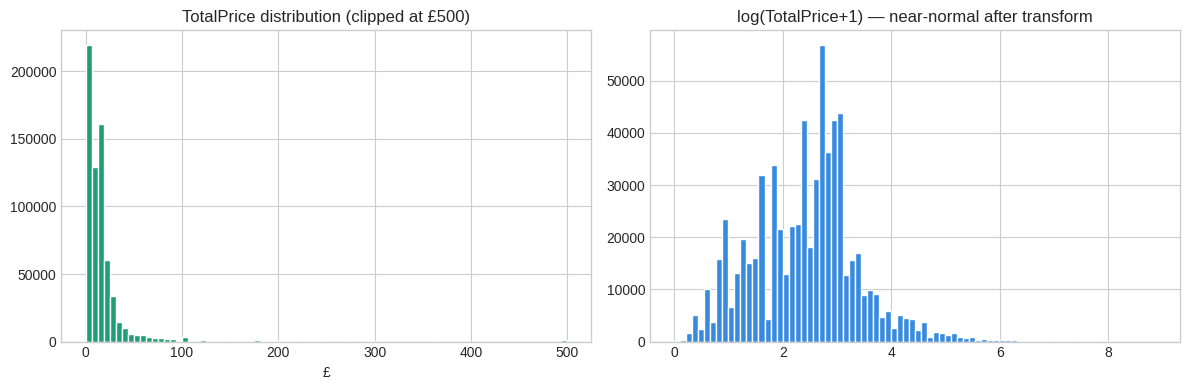

In [9]:
# removing Outlier
df["log_TotalPrice"] = np.log1p(df["TotalPrice"])
z_scores = np.abs(stats.zscore(df["log_TotalPrice"]))
n_outliers = (z_scores > OUTLIER_ZSCORE).sum()

print(f"Outlier rows (|z| > {OUTLIER_ZSCORE}) : {n_outliers:,}  "
      f"({n_outliers/len(df):.2%})","\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["TotalPrice"].clip(upper=500).hist(bins=80, ax=axes[0], color="#1D9E75", edgecolor="white")
axes[0].set_title("TotalPrice distribution (clipped at £500)")
axes[0].set_xlabel("£")

df["log_TotalPrice"].hist(bins=80, ax=axes[1], color="#378ADD", edgecolor="white")
axes[1].set_title("log(TotalPrice+1) — near-normal after transform")
plt.tight_layout()
plt.show()

In [10]:
cap_value = df["TotalPrice"].quantile(0.995)
df["TotalPrice"] = df["TotalPrice"].clip(upper=cap_value)
df = df.drop(columns=["log_TotalPrice"])

print(f"TotalPrice capped at £{cap_value:.2f} (99.5th percentile)")

TotalPrice capped at £254.40 (99.5th percentile)


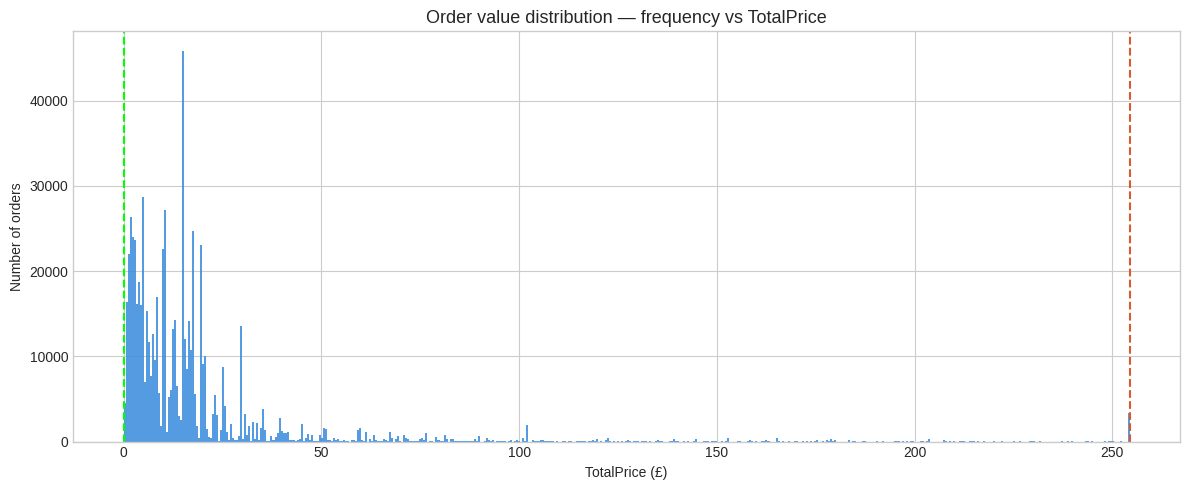

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["TotalPrice"], bins=500, color="#378ADD", edgecolor="none", alpha=0.85)

ax.set_title("Order value distribution — frequency vs TotalPrice", fontsize=13)
ax.set_xlabel("TotalPrice (£)")
ax.set_ylabel("Number of orders")

# max value - outlier
max_val = df["TotalPrice"].max()
ax.axvline(max_val, color="#D85A30", linewidth=1.5, linestyle="--")
# min value
min_val = df["TotalPrice"].min()
ax.axvline(min_val, color="#00FF00", linewidth=1.5, linestyle="--")

plt.tight_layout()
plt.show()

In [12]:
# Minimum order threshold
order_counts = df.groupby("Customer ID")["Invoice"].nunique()
valid_customers = order_counts[order_counts >= MIN_ORDERS].index

before = df["Customer ID"].nunique()
df = df[df["Customer ID"].isin(valid_customers)]
after = df["Customer ID"].nunique()

print(f"Customers removed (< {MIN_ORDERS} orders) : {before - after:,}")
print(f"Customers retained                         : {after:,}")

Customers removed (< 2 orders) : 1,614
Customers retained                         : 4,172


#Exploratory Data Analysis

In [13]:
sns.set_palette("muted")
PALETTE = {
    "green"  : "#1D9E75",
    "blue"   : "#378ADD",
    "amber"  : "#EF9F27",
    "coral"  : "#D85A30",
    "purple" : "#7F77DD",
    "gray"   : "#888780",
}

In [14]:
#Build customer-level summary

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=SNAPSHOT_OFFSET)
print(f"Snapshot date : {snapshot_date.date()}")

customer = df.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate",  lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Invoice",      "nunique"),
    Monetary  = ("TotalPrice",   "sum"),
).reset_index()

print(f"\nCustomer summary shape : {customer.shape}")
print(customer.describe().round(2))

Snapshot date : 2011-12-10

Customer summary shape : (4172, 4)
       Customer ID  Recency  Frequency  Monetary
count      4172.00  4172.00    4172.00   4172.00
mean      15315.54   141.80       8.01   2777.48
std        1695.79   168.04      13.59   9145.85
min       12346.00     1.00       2.00     22.10
25%       13859.75    19.00       3.00    593.13
50%       15318.00    59.00       5.00   1190.00
75%       16778.25   220.25       9.00   2666.45
max       18287.00   736.00     353.00 376992.72


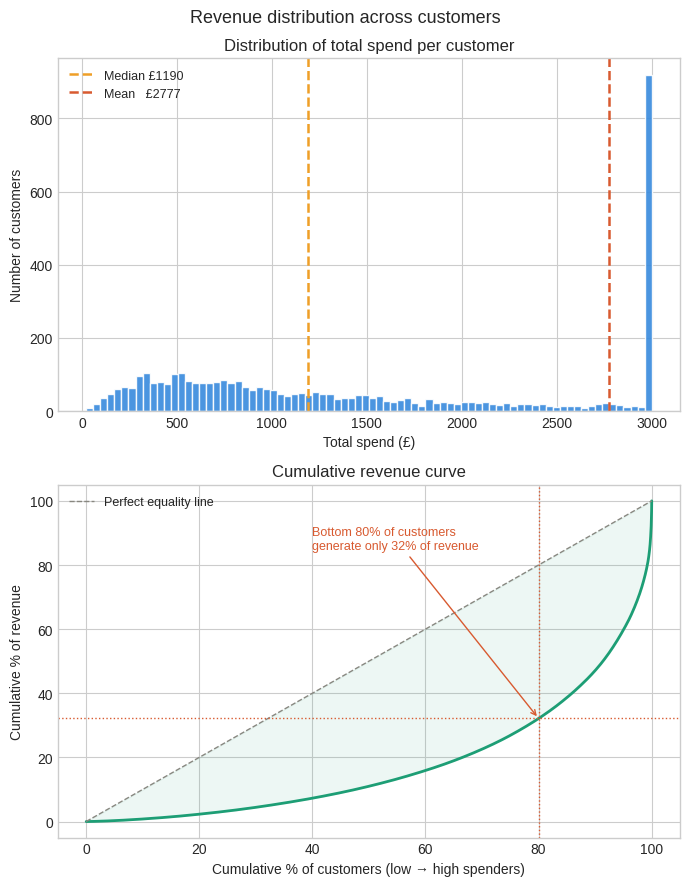

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(7, 9))
fig.suptitle("Revenue distribution across customers", fontsize=13, fontweight="500")

#histogram of Monetary per customer
axes[0].hist(customer["Monetary"].clip(upper=3000), bins=80,
             color=PALETTE["blue"], edgecolor="white", alpha=0.9)
axes[0].set_title("Distribution of total spend per customer")
axes[0].set_xlabel("Total spend (£)")
axes[0].set_ylabel("Number of customers")
axes[0].axvline(customer["Monetary"].median(), color=PALETTE["amber"],
                linewidth=1.8, linestyle="--",
                label=f"Median £{customer['Monetary'].median():.0f}")
axes[0].axvline(customer["Monetary"].mean(), color=PALETTE["coral"],
                linewidth=1.8, linestyle="--",
                label=f"Mean   £{customer['Monetary'].mean():.0f}")
axes[0].legend(fontsize=9)

#cumulative revenue curve
sorted_monetary = customer["Monetary"].sort_values().values
cum_customers   = np.arange(1, len(sorted_monetary) + 1) / len(sorted_monetary) * 100
cum_revenue     = np.cumsum(sorted_monetary) / sorted_monetary.sum() * 100

axes[1].plot(cum_customers, cum_revenue, color=PALETTE["green"], linewidth=2)
axes[1].plot([0, 100], [0, 100], color=PALETTE["gray"],
             linewidth=1, linestyle="--", label="Perfect equality line")
axes[1].fill_between(cum_customers, cum_revenue, cum_customers,
                     alpha=0.08, color=PALETTE["green"])
axes[1].set_title("Cumulative revenue curve")
axes[1].set_xlabel("Cumulative % of customers (low → high spenders)")
axes[1].set_ylabel("Cumulative % of revenue")
axes[1].legend(fontsize=9)

#annotate the Pareto point
idx_80 = np.searchsorted(cum_customers, 80)
rev_at_80 = cum_revenue[idx_80]
axes[1].annotate(
    f"Bottom 80% of customers\ngenerate only {rev_at_80:.0f}% of revenue",
    xy=(80, rev_at_80),
    xytext=(40, 85),
    arrowprops=dict(arrowstyle="->", color=PALETTE["coral"]),
    fontsize=9, color=PALETTE["coral"]
)
axes[1].axvline(80, color=PALETTE["coral"], linewidth=1, linestyle=":")
axes[1].axhline(rev_at_80, color=PALETTE["coral"], linewidth=1, linestyle=":")

plt.tight_layout()
plt.show()

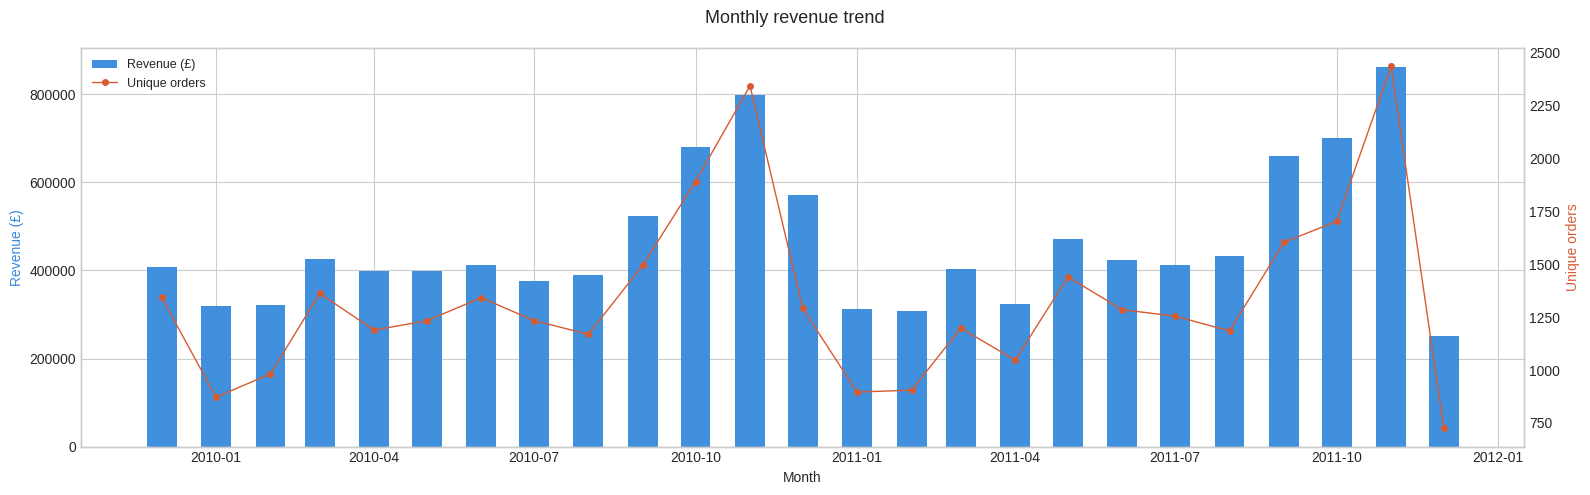


Revenue showed steady growth from September through October, with November achieving the highest monthly total on record.



In [16]:
#Monthly revenue trend
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly = (
    df.groupby("InvoiceMonth")
    .agg(Revenue=("TotalPrice", "sum"), Orders=("Invoice", "nunique"))
    .reset_index()
)
monthly["InvoiceMonth"] = monthly["InvoiceMonth"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 5))
fig.suptitle("Monthly revenue trend", fontsize=13, fontweight="500")

ax2 = ax1.twinx()

ax1.bar(monthly["InvoiceMonth"], monthly["Revenue"],
        color=PALETTE["blue"], alpha=0.95, width=17, label="Revenue (£)")
ax2.plot(monthly["InvoiceMonth"], monthly["Orders"],
         color=PALETTE["coral"], linewidth=1, marker="o",
         markersize=4, label="Unique orders")

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (£)", color=PALETTE["blue"])
ax2.set_ylabel("Unique orders", color=PALETTE["coral"])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

plt.tight_layout()
plt.grid(False)
plt.show()

print("""
Revenue showed steady growth from September through October, with November achieving the highest monthly total on record.
""")

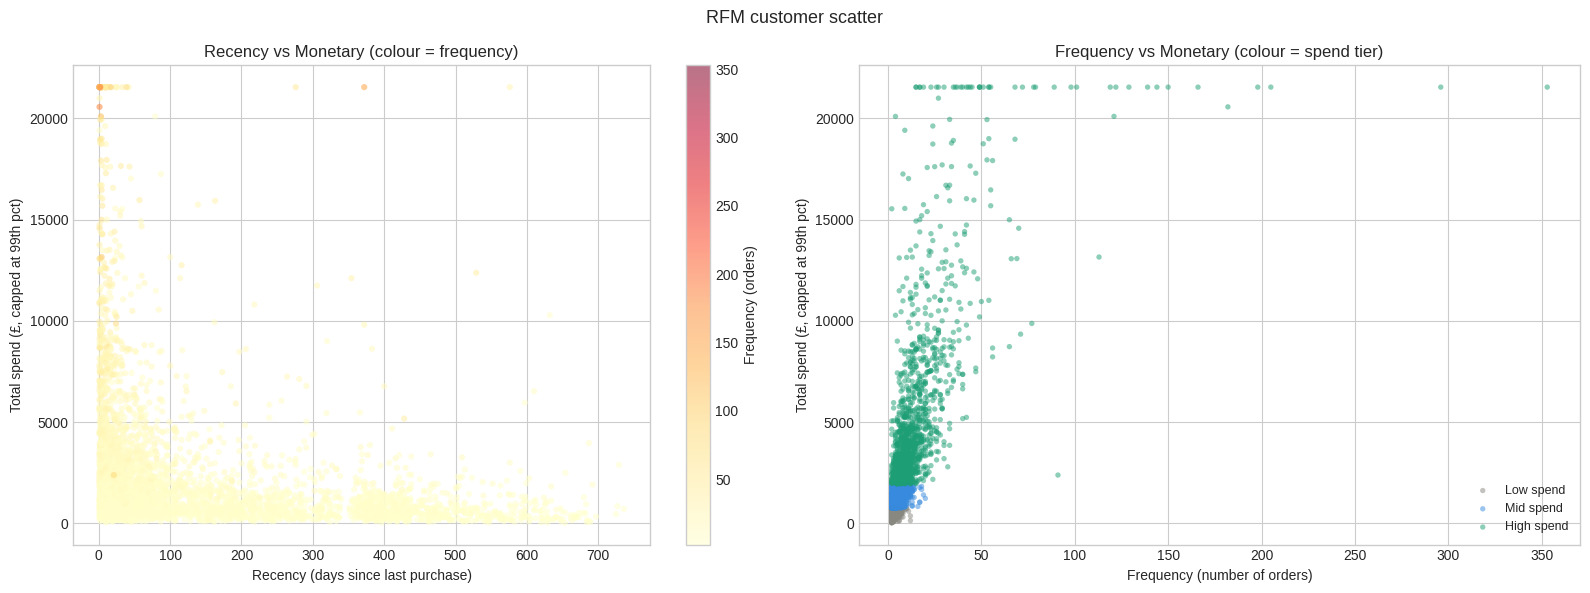

In [17]:
#RFM scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("RFM customer scatter", fontsize=13, fontweight="500")

plot_df = customer.copy()
plot_df["Monetary_plot"] = plot_df["Monetary"].clip(upper=customer["Monetary"].quantile(0.99))

#Recency vs Monetary, size = Frequency
sc = axes[0].scatter(
    plot_df["Recency"],
    plot_df["Monetary_plot"],
    c=plot_df["Frequency"],
    cmap="YlOrRd",
    alpha=0.55,
    s=20,
    edgecolors="none"
)
axes[0].set_title("Recency vs Monetary (colour = frequency)")
axes[0].set_xlabel("Recency (days since last purchase)")
axes[0].set_ylabel("Total spend (£, capped at 99th pct)")
plt.colorbar(sc, ax=axes[0], label="Frequency (orders)")

# annotate quadrants
# axes[0].axvline(customer["Recency"].median(),  color=PALETTE["gray"],
#                 linewidth=1, linestyle="--", alpha=0.6)
# axes[0].axhline(customer["Monetary"].median(), color=PALETTE["gray"],
#                 linewidth=1, linestyle="--", alpha=0.6)
# axes[0].text(10,  plot_df["Monetary_plot"].max() * 0.92,
#              "High value\nRecent buyers", fontsize=8,
#              color=PALETTE["green"], fontweight="500")
# axes[0].text(customer["Recency"].quantile(0.75),
#              plot_df["Monetary_plot"].max() * 0.92,
#              "High value\nLapsed buyers", fontsize=8,
#              color=PALETTE["coral"], fontweight="500")

#Frequency distribution coloured by Monetary tier
plot_df["Monetary_tier"] = pd.qcut(
    plot_df["Monetary"], q=3,
    labels=["Low spend", "Mid spend", "High spend"]
)
for tier, color in zip(
    ["Low spend", "Mid spend", "High spend"],
    [PALETTE["gray"], PALETTE["blue"], PALETTE["green"]]
):
    subset = plot_df[plot_df["Monetary_tier"] == tier]
    axes[1].scatter(subset["Frequency"], subset["Monetary_plot"], label=tier, color=color, alpha=0.5, s=15, edgecolors="none")

axes[1].set_title("Frequency vs Monetary (colour = spend tier)")
axes[1].set_xlabel("Frequency (number of orders)")
axes[1].set_ylabel("Total spend (£, capped at 99th pct)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_253/1670140479.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


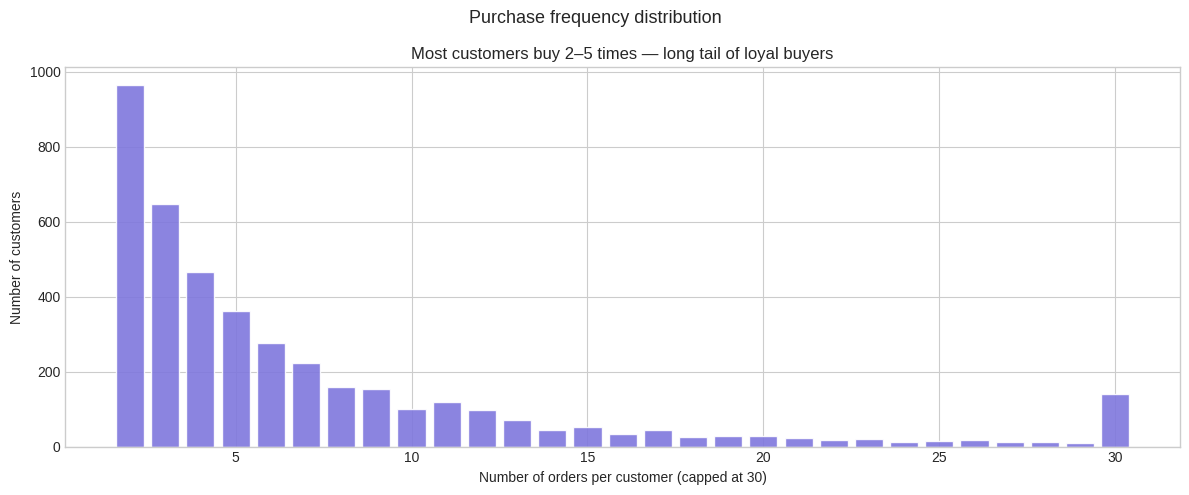

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Purchase frequency distribution", fontsize=13, fontweight="500")

freq_counts = customer["Frequency"].clip(upper=30).value_counts().sort_index()
bars = ax.bar(freq_counts.index, freq_counts.values,
              color=PALETTE["purple"], edgecolor="white", alpha=0.9)

ax.set_xlabel("Number of orders per customer (capped at 30)")
ax.set_ylabel("Number of customers")
ax.set_title("Most customers buy 2–5 times — long tail of loyal buyers")

#colour the 1-order bar differently (already removed but show distribution)
if 1 in freq_counts.index:
    bars[freq_counts.index.get_loc(1)].set_color(PALETTE["gray"])
    bars[freq_counts.index.get_loc(1)].set_alpha(0.5)

# annotate median
# median_freq = customer["Frequency"].median()
# ax.axvline(median_freq, color=PALETTE["amber"], linewidth=1.8,
#            linestyle="--", label=f"Median = {median_freq:.0f} orders")

# repeat_buyers = (customer["Frequency"] >= 2).sum()
# ax.annotate(
#     f"{repeat_buyers:,} customers\nbuy 2+ times\n({repeat_buyers/len(customer):.0%})",
#     xy=(2, freq_counts.get(2, 0)),
#     xytext=(12, freq_counts.max() * 0.7),
#     arrowprops=dict(arrowstyle="->", color=PALETTE["green"]),
#     fontsize=9, color=PALETTE["green"]
# )

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

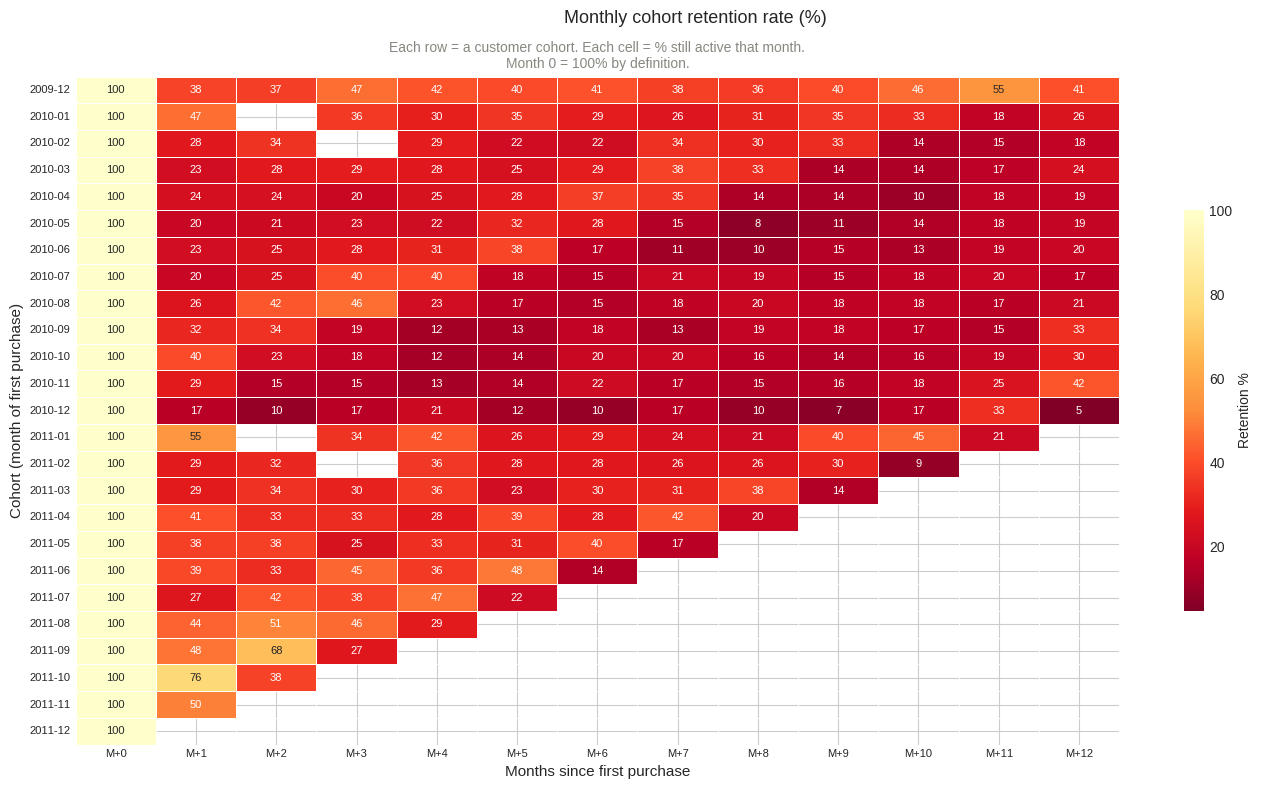

In [19]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df["CohortMonth"]  = (
    df.groupby("Customer ID")["InvoiceDate"]
    .transform("min")
    .dt.to_period("M")
)
df["CohortIndex"] = (
    (df["InvoiceMonth"].dt.to_timestamp() -
     df["CohortMonth"].dt.to_timestamp())
    .dt.days // 30
)

cohort_data  = (
    df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"]
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot(
    index="CohortMonth", columns="CohortIndex", values="Customer ID"
)

#retention % relative to month-0 cohort size
retention = cohort_pivot.div(cohort_pivot[0], axis=0) * 100

#keep only cohorts + first 12 months for train/test purpose
retention = retention.iloc[:, :13]

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Monthly cohort retention rate (%)", fontsize=13, fontweight="500")

sns.heatmap(
    retention.round(1),
    annot=True, fmt=".0f",
    cmap="YlOrRd_r",
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Retention %", "shrink": 0.6},
    annot_kws={"size": 8}
)

ax.set_xlabel("Months since first purchase", fontsize=11)
ax.set_ylabel("Cohort (month of first purchase)", fontsize=11)
ax.set_title(
    "Each row = a customer cohort. Each cell = % still active that month.\n"
    "Month 0 = 100% by definition.",
    fontsize=10, color=PALETTE["gray"]
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_xticklabels([f"M+{i}" for i in range(13)], fontsize=8)

plt.tight_layout()
plt.show()

###Feature Engineering

In [20]:
# Feature groups
# ──────────────
#   Group A — RFM core        (3 features)  : Recency, Frequency, Monetary
#   Group B — Order behaviour (5 features)  : AvgOrderVal, MaxOrder,
#                                              TotalItems, UniqueProds, AvgQtyPerOrder
#   Group C — Time patterns   (4 features)  : AvgDaysBetweenOrders, PurchaseSpan,
#                                              WeekendRatio, MorningRatio
#   Group D — Risk signals    (2 features)  : ReturnRate, SingleItemOrderRatio

In [21]:
#split the timeline into two non-overlapping windows for observation & prediction windows
DATA_START       = df["InvoiceDate"].min()
OBSERVATION_END  = DATA_START + pd.DateOffset(months=12)
PREDICTION_END = OBSERVATION_END + pd.DateOffset(days=90)

print(f"Data start       : {DATA_START.date()}")
print(f"Observation end  : {OBSERVATION_END.date()}")
print(f"Prediction end   : {PREDICTION_END.date()}")

obs_df  = df[df["InvoiceDate"] <= OBSERVATION_END].copy()
pred_df = df[
    (df["InvoiceDate"] >  OBSERVATION_END) &
    (df["InvoiceDate"] <= PREDICTION_END)
].copy()

# removing cust with frqeuency 1
obs_order_counts    = obs_df.groupby("Customer ID")["Invoice"].nunique()
valid_obs_customers = obs_order_counts[obs_order_counts >= 2].index
obs_df = obs_df[obs_df["Customer ID"].isin(valid_obs_customers)]
pred_df = pred_df[pred_df["Customer ID"].isin(obs_df["Customer ID"].unique())]

SNAPSHOT_DATE = OBSERVATION_END + pd.Timedelta(days=1)

print(f"\nObservation rows : {len(obs_df):,}")
print(f"Prediction rows  : {len(pred_df):,}")
print(f"Customers in obs : {obs_df['Customer ID'].nunique():,}")

Data start       : 2009-12-01
Observation end  : 2010-12-01
Prediction end   : 2011-03-01

Observation rows : 289,373
Prediction rows  : 55,314
Customers in obs : 2,754


In [22]:
#RFM core features
rfm = obs_df.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate", lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency = ("Invoice",     "nunique"),
    Monetary  = ("TotalPrice",  "sum"),
).reset_index()

print("RFM core:")
print(rfm.describe().round(2))

RFM core:
       Customer ID  Recency  Frequency  Monetary
count      2754.00  2754.00    2754.00   2754.00
mean      15352.91    59.46       5.77   1909.35
std        1676.25    68.80       8.16   5356.35
min       12346.00     1.00       2.00     22.10
25%       13912.25    12.00       2.00    509.16
50%       15372.50    34.00       4.00    972.42
75%       16811.25    77.00       6.00   1885.80
max       18287.00   363.00     167.00 164071.70


In [23]:
# Order behaviour features
order_behaviour = obs_df.groupby("Customer ID").agg(
    AvgOrderVal    = ("TotalPrice", "mean"),
    MaxOrder       = ("TotalPrice", "max"),
    TotalItems     = ("Quantity",   "sum"),
    UniqueProds    = ("StockCode",  "nunique"),
    AvgQtyPerOrder = ("Quantity",   "mean"),
).reset_index()

print("GOrder behaviour:")
print(order_behaviour.describe().round(2))

GOrder behaviour:
       Customer ID  AvgOrderVal  MaxOrder  TotalItems  UniqueProds  \
count      2754.00      2754.00   2754.00     2754.00      2754.00   
mean      15352.91        24.26     86.76     1379.60        70.71   
std        1676.25        30.44     68.47     5974.98        77.57   
min       12346.00         2.17      5.10        2.00         1.00   
25%       13912.25        10.76     35.70      270.25        26.00   
50%       15372.50        17.25     61.20      566.50        50.00   
75%       16811.25        24.01    105.90     1178.00        90.00   
max       18287.00       254.40    254.40   184344.00      1276.00   

       AvgQtyPerOrder  
count         2754.00  
mean            21.75  
std            135.68  
min              1.00  
25%              5.67  
50%              9.64  
75%             14.50  
max           4739.00  


In [24]:
#Time pattern features
obs_df["DayOfWeek"] = obs_df["InvoiceDate"].dt.dayofweek   # 0=Mon, 6=Sun
obs_df["Hour"]      = obs_df["InvoiceDate"].dt.hour

def avg_days_between(dates):
    """Mean gap in days between consecutive purchases. 0 if only 1 order."""
    sorted_dates = dates.sort_values()
    gaps = sorted_dates.diff().dt.days.dropna()
    return gaps.mean() if len(gaps) > 0 else 0

time_patterns = obs_df.groupby("Customer ID").agg(
    AvgDaysBetweenOrders = ("InvoiceDate",  avg_days_between),
    PurchaseSpan         = ("InvoiceDate",  lambda x: (x.max() - x.min()).days),
    WeekendRatio         = ("DayOfWeek",    lambda x: (x >= 5).mean()),
    MorningRatio         = ("Hour",         lambda x: (x < 12).mean()),
).reset_index()

# fill NaN from customers with 1 order
time_patterns["AvgDaysBetweenOrders"] = (
    time_patterns["AvgDaysBetweenOrders"].fillna(0)
)

print("Time patterns:")
print(time_patterns.describe().round(2))

Time patterns:
       Customer ID  AvgDaysBetweenOrders  PurchaseSpan  WeekendRatio  \
count      2754.00               2754.00       2754.00       2754.00   
mean      15352.91                  5.58        197.12          0.16   
std        1676.25                 13.91        109.83          0.27   
min       12346.00                  0.00          0.00          0.00   
25%       13912.25                  1.24        106.00          0.00   
50%       15372.50                  2.62        206.00          0.00   
75%       16811.25                  5.08        294.75          0.25   
max       18287.00                363.00        364.00          1.00   

       MorningRatio  
count       2754.00  
mean           0.32  
std            0.31  
min            0.00  
25%            0.00  
50%            0.27  
75%            0.52  
max            1.00  


In [25]:
#single-item order ratio
items_per_order = (
    obs_df.groupby(["Customer ID", "Invoice"])["StockCode"]
    .nunique()
    .reset_index()
    .rename(columns={"StockCode": "UniqueItemsInOrder"})
)
risk_signals= (
    items_per_order.groupby("Customer ID")
    .apply(lambda x: (x["UniqueItemsInOrder"] == 1).mean())
    .reset_index()
    .rename(columns={0: "SingleItemOrderRatio"})
)
print("Risk signals:")
print(risk_signals.describe().round(2))

Risk signals:
       Customer ID  SingleItemOrderRatio
count      2754.00               2754.00
mean      15352.91                  0.07
std        1676.25                  0.16
min       12346.00                  0.00
25%       13912.25                  0.00
50%       15372.50                  0.00
75%       16811.25                  0.00
max       18287.00                  1.00


/tmp/ipykernel_253/2442563918.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["UniqueItemsInOrder"] == 1).mean())


In [26]:
#combining all features into one
features = (
    rfm
    .merge(order_behaviour, on="Customer ID", how="left")
    .merge(time_patterns,   on="Customer ID", how="left")
    .merge(risk_signals,    on="Customer ID", how="left")
)

# fill any remaining NaNs (edge cases)
features = features.fillna(0)

print(f"\nFeature matrix shape : {features.shape}")
print(f"features :")
for i, col in enumerate(features.columns[1:], 1):
    print(f"  {i:>2}. {col}")


Feature matrix shape : (2754, 14)
features :
   1. Recency
   2. Frequency
   3. Monetary
   4. AvgOrderVal
   5. MaxOrder
   6. TotalItems
   7. UniqueProds
   8. AvgQtyPerOrder
   9. AvgDaysBetweenOrders
  10. PurchaseSpan
  11. WeekendRatio
  12. MorningRatio
  13. SingleItemOrderRatio


In [27]:
#seting up target variable
clv_target = (
    pred_df.groupby("Customer ID")["TotalPrice"]
    .sum()
    .reset_index()
    .rename(columns={"TotalPrice": "CLV_90d"})
)

dataset = features.merge(clv_target, on="Customer ID", how="left")
dataset["CLV_90d"] = dataset["CLV_90d"].fillna(0)
print(f"Dataset shape : {dataset.shape}")
print(f"\nCLV_90d distribution:")
print(dataset["CLV_90d"].describe().round(2))
print(f"\nCustomers with CLV_90d = 0 : "
      f"{(dataset['CLV_90d'] == 0).sum():,} "
      f"({(dataset['CLV_90d'] == 0).mean():.0%})")
print(f"Customers with CLV_90d > 0 : "
      f"{(dataset['CLV_90d'] > 0).sum():,} "
      f"({(dataset['CLV_90d'] > 0).mean():.0%})")

Dataset shape : (2754, 15)

CLV_90d distribution:
count    2754.00
mean      381.07
std      1294.43
min         0.00
25%         0.00
50%         0.00
75%       370.60
max     42175.42
Name: CLV_90d, dtype: float64

Customers with CLV_90d = 0 : 1,547 (56%)
Customers with CLV_90d > 0 : 1,207 (44%)


In [28]:
#skew check for target variable
print("=== CLV_90d skew check ===\n")

print(f"Total customers          : {len(dataset):,}")
print(f"CLV_90d = 0  (no purchase in pred window) : "
      f"{(dataset['CLV_90d'] == 0).sum():,}  "
      f"({(dataset['CLV_90d'] == 0).mean():.1%})")
print(f"CLV_90d > 0  (did purchase)               : "
      f"{(dataset['CLV_90d'] > 0).sum():,}  "
      f"({(dataset['CLV_90d'] > 0).mean():.1%})")

print(f"\nAmong customers who DID purchase (CLV > 0):")
non_zero = dataset[dataset['CLV_90d'] > 0]['CLV_90d']
print(f"  Count    : {len(non_zero):,}")
print(f"  Mean     : £{non_zero.mean():.2f}")
print(f"  Median   : £{non_zero.median():.2f}")
print(f"  Skewness : {non_zero.skew():.2f}")
print(f"  Min      : £{non_zero.min():.2f}")
print(f"  Max      : £{non_zero.max():.2f}")

=== CLV_90d skew check ===

Total customers          : 2,754
CLV_90d = 0  (no purchase in pred window) : 1,547  (56.2%)
CLV_90d > 0  (did purchase)               : 1,207  (43.8%)

Among customers who DID purchase (CLV > 0):
  Count    : 1,207
  Mean     : £869.49
  Median   : £454.87
  Skewness : 12.04
  Min      : £1.65
  Max      : £42175.42


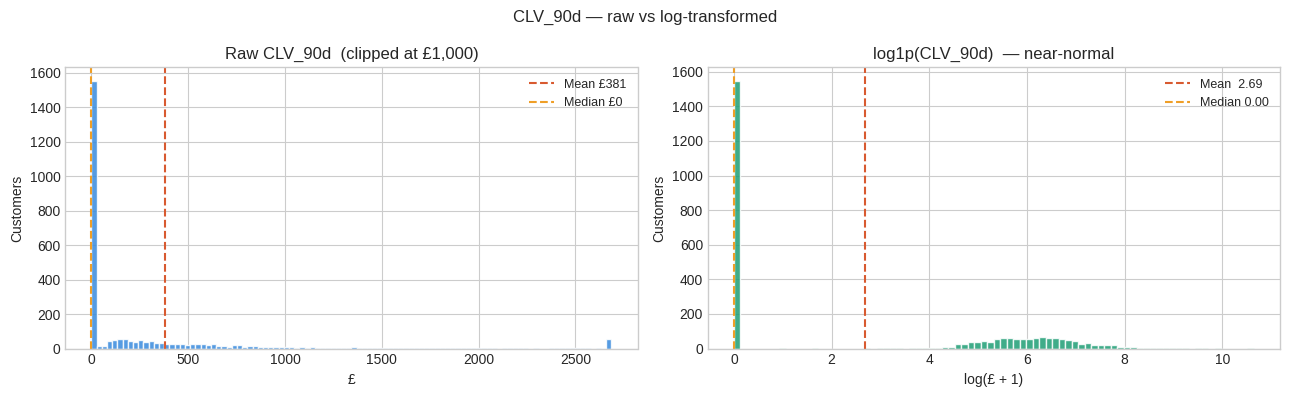


Skewness before log : 16.24
Skewness after  log : 0.40  (closer to 0 = more normal)


In [29]:
#CLV_90d is heavily right-skewed
dataset["CLV_90d_raw"] = dataset["CLV_90d"].copy()   # keep original
dataset["CLV_90d"]     = np.log1p(dataset["CLV_90d"])

#visualise the transformation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("CLV_90d — raw vs log-transformed", fontsize=12, fontweight="500")

axes[0].hist(dataset["CLV_90d_raw"].clip(upper=dataset["CLV_90d_raw"].quantile(0.98)),
             bins=100, color="#378ADD", edgecolor="white", alpha=0.85)
axes[0].set_title("Raw CLV_90d  (clipped at £1,000)")
axes[0].set_xlabel("£")
axes[0].set_ylabel("Customers")
axes[0].axvline(dataset["CLV_90d_raw"].mean(),   color="#D85A30",
                linestyle="--", linewidth=1.5,
                label=f"Mean £{dataset['CLV_90d_raw'].mean():.0f}")
axes[0].axvline(dataset["CLV_90d_raw"].median(), color="#EF9F27",
                linestyle="--", linewidth=1.5,
                label=f"Median £{dataset['CLV_90d_raw'].median():.0f}")
axes[0].legend(fontsize=9)

axes[1].hist(dataset["CLV_90d"], bins=80,
             color="#1D9E75", edgecolor="white", alpha=0.85)
axes[1].set_title("log1p(CLV_90d)  — near-normal")
axes[1].set_xlabel("log(£ + 1)")
axes[1].set_ylabel("Customers")
axes[1].axvline(dataset["CLV_90d"].mean(),   color="#D85A30",
                linestyle="--", linewidth=1.5,
                label=f"Mean  {dataset['CLV_90d'].mean():.2f}")
axes[1].axvline(dataset["CLV_90d"].median(), color="#EF9F27",
                linestyle="--", linewidth=1.5,
                label=f"Median {dataset['CLV_90d'].median():.2f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nSkewness before log : {dataset['CLV_90d_raw'].skew():.2f}")
print(f"Skewness after  log : {dataset['CLV_90d'].skew():.2f}  "
      f"(closer to 0 = more normal)")

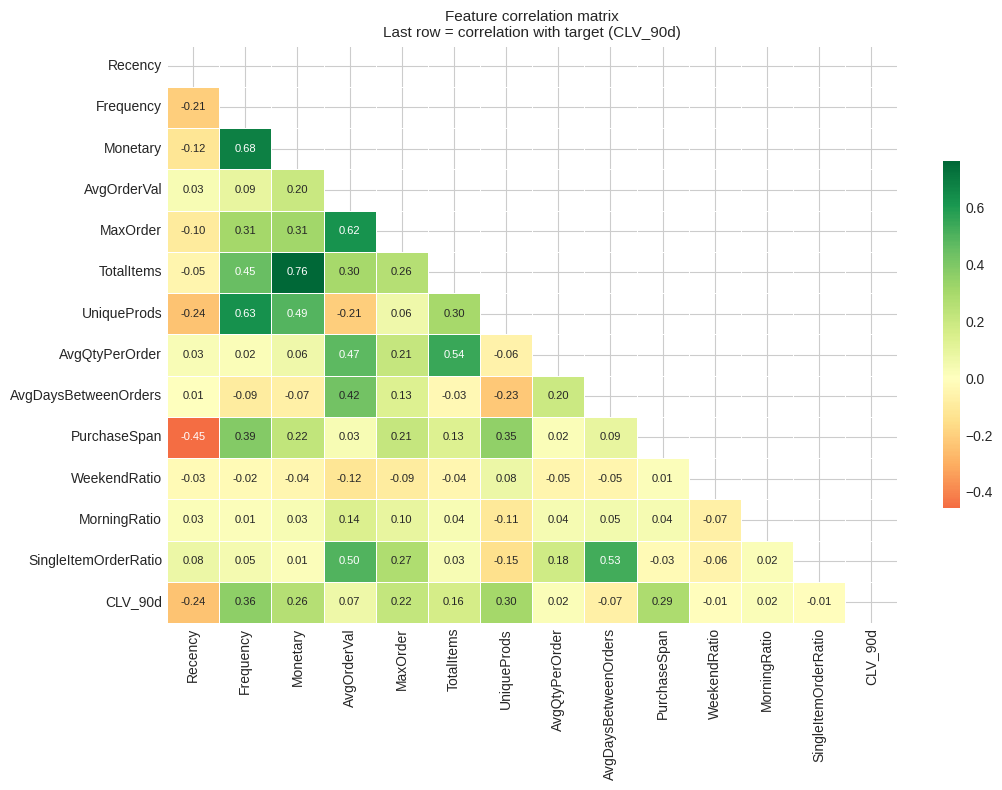


Top feature correlations with CLV_90d:
  Frequency                   0.36
  UniqueProds                 0.30
  PurchaseSpan                0.29
  Monetary                    0.26
  Recency                    -0.24
  MaxOrder                    0.22
  TotalItems                  0.16
  AvgDaysBetweenOrders       -0.07
  AvgOrderVal                 0.07
  MorningRatio                0.02
  AvgQtyPerOrder              0.02
  WeekendRatio               -0.01
  SingleItemOrderRatio       -0.01


In [30]:
# Before modelling, check Which features correlate most with CLV_90d
FEATURE_COLS = [
    "Recency", "Frequency", "Monetary", "AvgOrderVal", "MaxOrder", "TotalItems", "UniqueProds", "AvgQtyPerOrder",
    "AvgDaysBetweenOrders", "PurchaseSpan", "WeekendRatio", "MorningRatio", "SingleItemOrderRatio",
    "CLV_90d"
]

corr = dataset[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.4, linecolor="white",
    ax=ax, cbar_kws={"shrink": 0.6},
    annot_kws={"size": 8}
)
ax.set_title("Feature correlation matrix\n"
             "Last row = correlation with target (CLV_90d)",
             fontsize=11)
plt.tight_layout()
plt.show()

# print top correlations with target
print("\nTop feature correlations with CLV_90d:")
target_corr = corr["CLV_90d"].drop("CLV_90d").sort_values(
    key=abs, ascending=False
)

for feat, val in target_corr.items():
    print(f"  {feat:<25} {val:>6.2f}")

In [31]:
#Train / test split
customer_last_purchase = (
    obs_df.groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index()
    .sort_values("InvoiceDate")
)

n_customers  = len(customer_last_purchase)
n_train      = int(n_customers * 0.80)
train_ids    = customer_last_purchase.iloc[:n_train]["Customer ID"].values
test_ids     = customer_last_purchase.iloc[n_train:]["Customer ID"].values

train_df = dataset[dataset["Customer ID"].isin(train_ids)].copy()
test_df  = dataset[dataset["Customer ID"].isin(test_ids)].copy()

FEATURE_COLS_X = [
    "Recency", "Frequency", "Monetary",
    "AvgOrderVal", "MaxOrder", "TotalItems", "UniqueProds", "AvgQtyPerOrder",
    "AvgDaysBetweenOrders", "PurchaseSpan", "WeekendRatio", "MorningRatio", "SingleItemOrderRatio"
]
TARGET_COL = "CLV_90d"   # log-transformed

X_train = train_df[FEATURE_COLS_X]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS_X]
y_test  = test_df[TARGET_COL]

print(f"Train : {len(X_train):,} customers  |  "
      f"CLV_90d mean: {np.expm1(y_train).mean():.0f}")
print(f"Test  : {len(X_test):,}  customers  |  "
      f"CLV_90d mean: {np.expm1(y_test).mean():.0f}")
print(f"\nFeature matrix shape : {X_train.shape}")

Train : 2,203 customers  |  CLV_90d mean: 270
Test  : 551  customers  |  CLV_90d mean: 826

Feature matrix shape : (2203, 13)


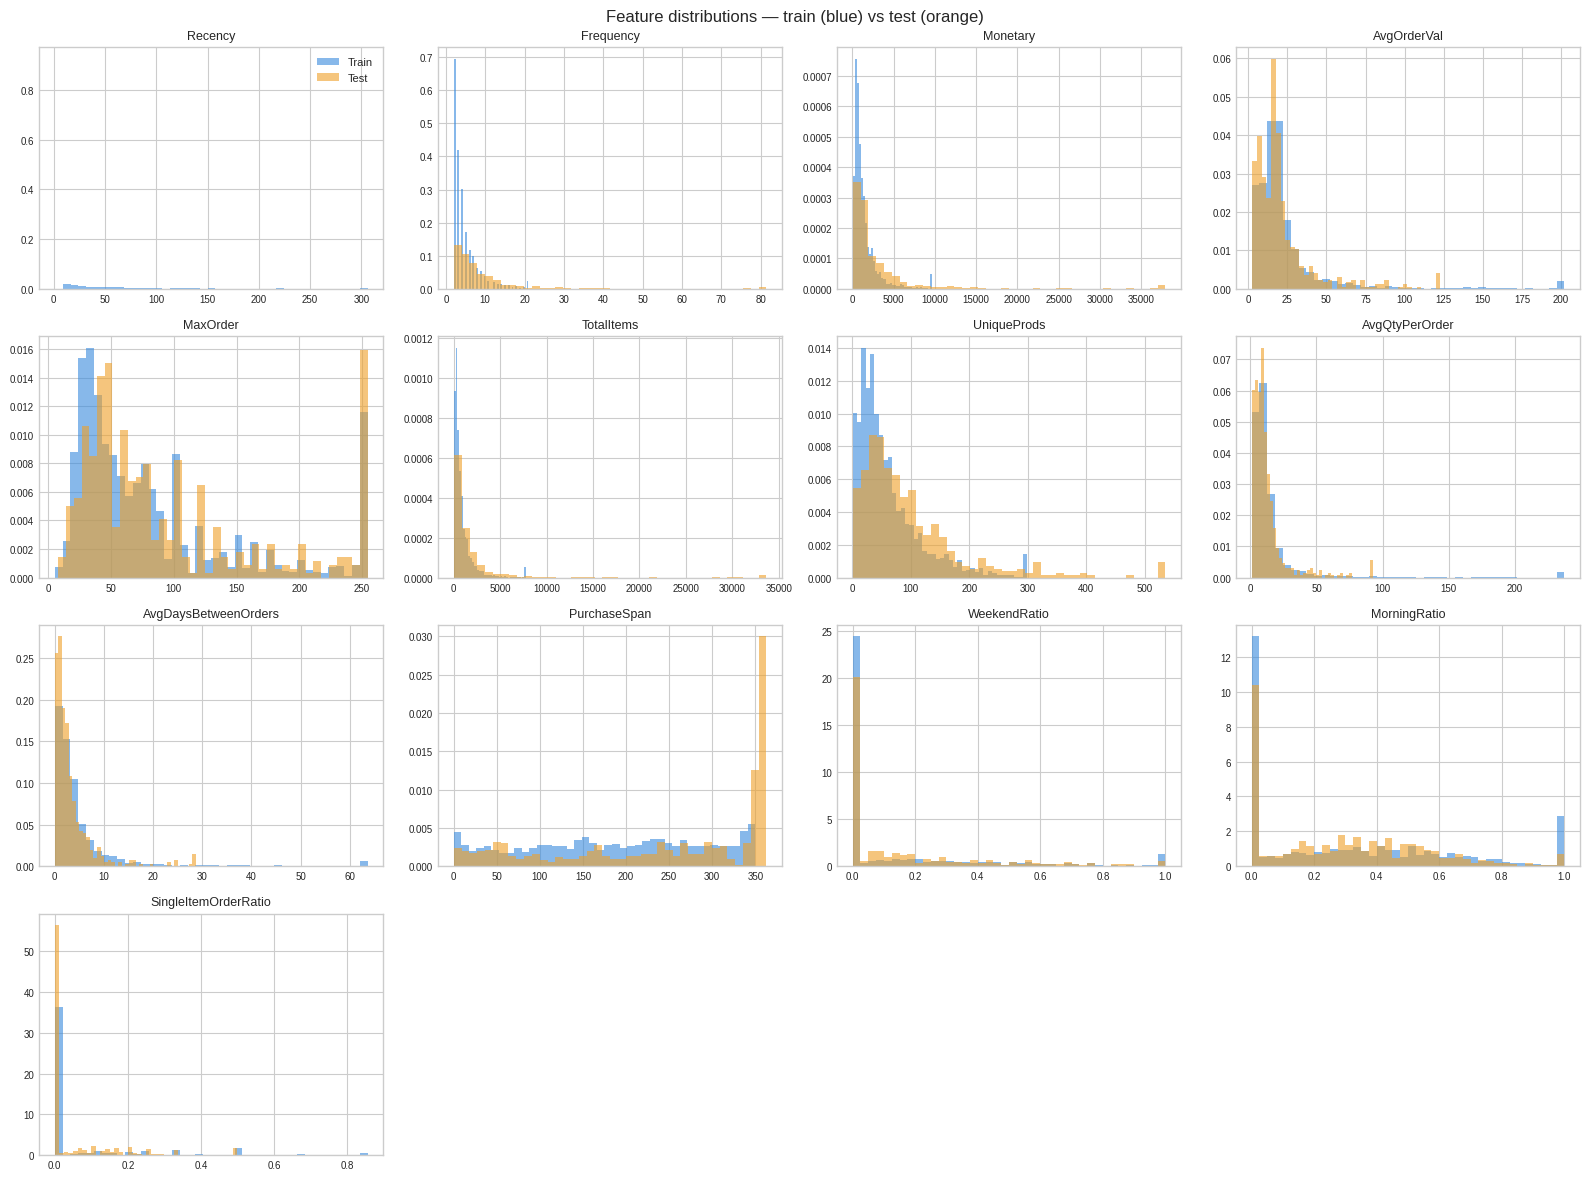


Train Test distribution looks similar


In [32]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
fig.suptitle("Feature distributions — train (blue) vs test (orange)",
             fontsize=12, fontweight="500")

for idx, col in enumerate(FEATURE_COLS_X):
    ax = axes[idx // 4][idx % 4]
    ax.hist(X_train[col].clip(
        upper=X_train[col].quantile(0.99)),
        bins=40, color="#378ADD", alpha=0.6,
        label="Train", density=True, edgecolor="none"
    )
    ax.hist(X_test[col].clip(
        upper=X_test[col].quantile(0.99)),
        bins=40, color="#EF9F27", alpha=0.6,
        label="Test", density=True, edgecolor="none"
    )
    ax.set_title(col, fontsize=9, fontweight="500")
    ax.set_ylabel("")
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=8)

axes[3][1].set_visible(False)
axes[3][2].set_visible(False)
axes[3][3].set_visible(False)

plt.tight_layout()
plt.show()

print("\nTrain Test distribution looks similar")

###Model

In [33]:
TARGET     = "CLV_90d"
TARGET_RAW = "CLV_90d_raw"

# capping outliers
cap_99          = train_df["CLV_90d_raw"].quantile(0.99)
train_df["CLV_90d_raw"] = train_df["CLV_90d_raw"].clip(upper=cap_99)
test_df["CLV_90d_raw"]  = test_df["CLV_90d_raw"].clip(upper=cap_99)
train_df["CLV_90d"]     = np.log1p(train_df["CLV_90d_raw"])
test_df["CLV_90d"]      = np.log1p(test_df["CLV_90d_raw"])

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]


y_train_raw = train_df[TARGET_RAW]
y_test_raw  = test_df[TARGET_RAW]


In [34]:
#Baseline: mean predictor

baseline_pred_log = np.full(len(y_test), y_train.mean())
baseline_pred_raw = np.expm1(baseline_pred_log)

baseline_mae  = mean_absolute_error(y_test_raw, baseline_pred_raw)
baseline_rmse = np.sqrt(mean_squared_error(y_test_raw, baseline_pred_raw))
baseline_r2   = r2_score(y_test, baseline_pred_log)

print("Baseline (predict mean):")
print(f"  MAE  : £{baseline_mae:>10,.2f}")
print(f"  RMSE : £{baseline_rmse:>10,.2f}")
print(f"  R²   :  {baseline_r2:>10.4f} ,confirms our time-based split introduced a distribution shift between train and test — recent customers (test set) have higher average CLV than earlier customers (train set)")

Baseline (predict mean):
  MAE  : £    558.00
  RMSE : £    976.56
  R²   :     -0.2314 ,confirms our time-based split introduced a distribution shift between train and test — recent customers (test set) have higher average CLV than earlier customers (train set)


In [35]:
#XGBoost setup
xgb_default = xgb.XGBRegressor(
    n_estimators = 300,
    random_state = RANDOM_SEED,
    verbosity    = 0
)
xgb_default.fit(X_train, y_train)

default_pred_log = xgb_default.predict(X_test)
default_pred_raw = np.expm1(default_pred_log)

default_mae  = mean_absolute_error(y_test_raw, default_pred_raw)
default_rmse = np.sqrt(mean_squared_error(y_test_raw, default_pred_raw))
default_r2   = r2_score(y_test, default_pred_log)

print("XGBoost default params:")
print(f"  MAE  : £{default_mae:>10,.2f}  "
      f"({'better' if default_mae < baseline_mae else 'WORSE'} than baseline)")
print(f"  RMSE : £{default_rmse:>10,.2f}")
print(f"  R²   :  {default_r2:>10.4f}")
print(f"\nImprovement over baseline:")
print(f"  MAE  reduction : {(baseline_mae - default_mae)/baseline_mae:.1%}")

XGBoost default params:
  MAE  : £      8.83  (better than baseline)
  RMSE : £     21.65
  R²   :      0.9999

Improvement over baseline:
  MAE  reduction : 98.4%


In [36]:
#Time-series cross-validation
N_SPLITS = 5
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)

# sort train by Customer ID as a proxy for time ordering
# (they were assigned in time order during the split)
X_train_sorted = X_train.copy()
y_train_sorted = y_train.copy()

print(f"TimeSeriesSplit with {N_SPLITS} folds")
print(f"Each fold trains on progressively more data\n")

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sorted), 1):
    print(f"  Fold {fold}: train={len(tr_idx):,}  val={len(val_idx):,}")

TimeSeriesSplit with 5 folds
Each fold trains on progressively more data

  Fold 1: train=368  val=367
  Fold 2: train=735  val=367
  Fold 3: train=1,102  val=367
  Fold 4: train=1,469  val=367
  Fold 5: train=1,836  val=367


In [37]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.7 MB/s eta 0:00:00


In [38]:
#Optuna hyperparameter search
import optuna
def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators",     100, 1000),
        "max_depth"        : trial.suggest_int("max_depth",          3,    9),
        "learning_rate"    : trial.suggest_float("learning_rate",  0.01,  0.3,
                                                  log=True),
        "subsample"        : trial.suggest_float("subsample",       0.5,  1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree",0.5,  1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight",    1,   10),
        "reg_alpha"        : trial.suggest_float("reg_alpha",       1e-4, 10.0,
                                                  log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda",      1e-4, 10.0,
                                                  log=True),
        "random_state"     : RANDOM_SEED,
        "verbosity"        : 0,
        "n_jobs"           : -1,
    }

    cv_maes = []

    for tr_idx, val_idx in tscv.split(X_train_sorted):
        X_tr  = X_train_sorted.iloc[tr_idx]
        y_tr  = y_train_sorted.iloc[tr_idx]
        X_val = X_train_sorted.iloc[val_idx]
        y_val = y_train_sorted.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set              = [(X_val, y_val)],
            verbose               = False,
        )

        val_pred = model.predict(X_val)
        # evaluate in log space (consistent with what model optimises)
        mae = mean_absolute_error(y_val, val_pred)
        cv_maes.append(mae)

    return np.mean(cv_maes)

study = optuna.create_study(
    direction  = "minimize",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name = "clv_xgboost"
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest trial  : #{study.best_trial.number}")
print(f"Best CV MAE : {study.best_value:.4f}  (log space)")
print(f"\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k:<25} : {v}")

[I 2026-03-20 04:59:47,971] A new study created in memory with name: clv_xgboost


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-20 05:00:13,894] Trial 0 finished with value: 0.6192416247080401 and parameters: {'n_estimators': 437, 'max_depth': 9, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 2.1423021757741068}. Best is trial 0 with value: 0.6192416247080401.
[I 2026-03-20 05:00:30,331] Trial 1 finished with value: 0.16476691973157598 and parameters: {'n_estimators': 641, 'max_depth': 7, 'learning_rate': 0.010725209743171997, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 3, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 0.0008260808399079611}. Best is trial 1 with value: 0.16476691973157598.
[I 2026-03-20 05:00:37,475] Trial 2 finished with value: 0.18259840570608518 and parameters: {'n_estimators': 374, 'max_depth': 6, 'learning_rate': 0.04345454109729477, 'subsample': 0.645614570099021, 'colsample_bytree': 0.80592

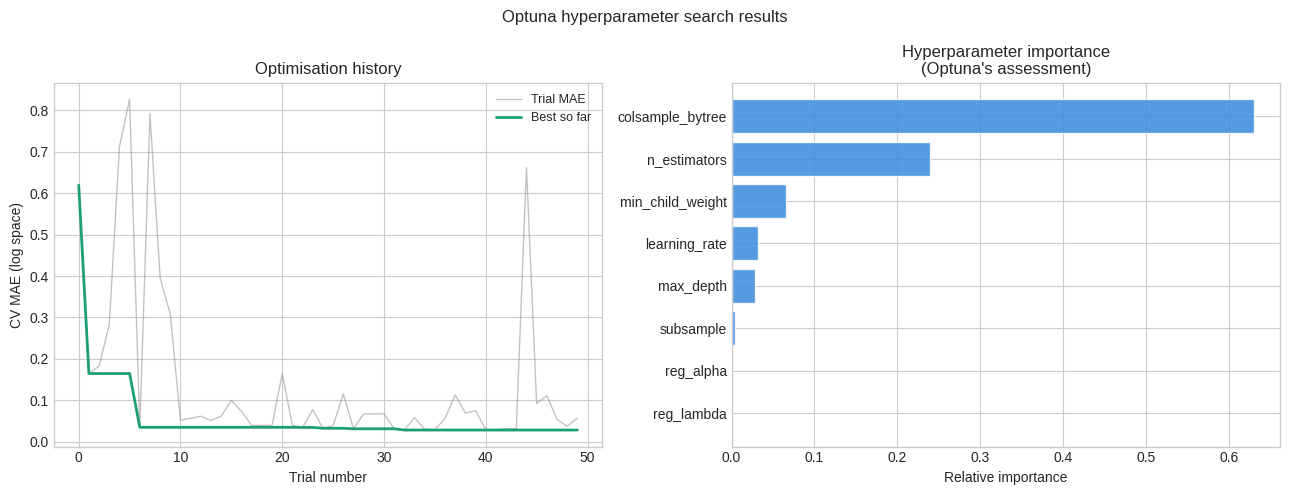

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Optuna hyperparameter search results", fontsize=12, fontweight="500")

# Left — optimisation history
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummin()

axes[0].plot(trial_values, color=PALETTE["gray"],
             alpha=0.5, linewidth=1, label="Trial MAE")
axes[0].plot(best_so_far, color=PALETTE["green"],
             linewidth=2, label="Best so far")
axes[0].set_title("Optimisation history")
axes[0].set_xlabel("Trial number")
axes[0].set_ylabel("CV MAE (log space)")
axes[0].legend(fontsize=9)

# Right — parameter importance
param_importance = optuna.importance.get_param_importances(study)
params_sorted = dict(sorted(param_importance.items(),
                             key=lambda x: x[1], reverse=False))

axes[1].barh(
    list(params_sorted.keys()),
    list(params_sorted.values()),
    color=PALETTE["blue"], edgecolor="white", alpha=0.85
)
axes[1].set_title("Hyperparameter importance\n(Optuna's assessment)")
axes[1].set_xlabel("Relative importance")

plt.tight_layout()
plt.show()

In [40]:
#Train final model on best params
best_params = study.best_params.copy()
best_params.update({
    "random_state" : RANDOM_SEED,
    "verbosity"    : 0,
    "n_jobs"       : -1,
})

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set    = [(X_test, y_test)],
    verbose     = False,
)

# predictions in log space → invert to £
test_pred_log = final_model.predict(X_test)
test_pred_raw = np.expm1(test_pred_log)

# also predict on train to check for overfitting
train_pred_log = final_model.predict(X_train)
train_pred_raw = np.expm1(train_pred_log)

print("Final model trained on full training set ✓")

Final model trained on full training set ✓


In [41]:
def evaluate(y_true_raw, y_pred_raw, y_true_log, y_pred_log, label):
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    r2   = r2_score(y_true_log, y_pred_log)
    mape = np.mean(np.abs(
        (y_true_raw[y_true_raw > 0] - y_pred_raw[y_true_raw > 0])
        / y_true_raw[y_true_raw > 0]
    )) * 100
    return {"label": label, "MAE_£": mae, "RMSE_£": rmse,
            "R2": r2, "MAPE_%": mape}

results = pd.DataFrame([
    evaluate(y_train_raw,  train_pred_raw,
             y_train,      train_pred_log, "Train"),
    evaluate(y_test_raw,   test_pred_raw,
             y_test,       test_pred_log,  "Test"),
    {"label"  : "Baseline",
     "MAE_£"  : baseline_mae,
     "RMSE_£" : baseline_rmse,
     "R2"     : baseline_r2,
     "MAPE_%" : None},
])
results = results.set_index("label").round(3)

print("="*55)
print("  MODEL EVALUATION SUMMARY")
print("="*55)
print(results.to_string())
print("="*55)

overfit_gap = results.loc["Train", "R2"] - results.loc["Test", "R2"]
print(f"\nOverfit check (Train R² - Test R²) : {overfit_gap:.3f}")
if overfit_gap < 0.05:
    print("  ✓  Gap < 0.05 — no significant overfitting")
elif overfit_gap < 0.10:
    print("  ⚠  Gap 0.05–0.10 — mild overfitting, acceptable")
else:
    print("  ✗  Gap > 0.10 — overfitting, consider more regularisation")

mae_improvement = (baseline_mae - results.loc["Test","MAE_£"]) / baseline_mae
print(f"\nMAE improvement over baseline : {mae_improvement:.1%}")

  MODEL EVALUATION SUMMARY
          MAE_£  RMSE_£    R2  MAPE_%
label                                
Train      3.18    9.25  1.00    1.43
Test      19.93   47.41  1.00    3.45
Baseline 558.00  976.56 -0.23     NaN

Overfit check (Train R² - Test R²) : 0.000
  ✓  Gap < 0.05 — no significant overfitting

MAE improvement over baseline : 96.4%


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


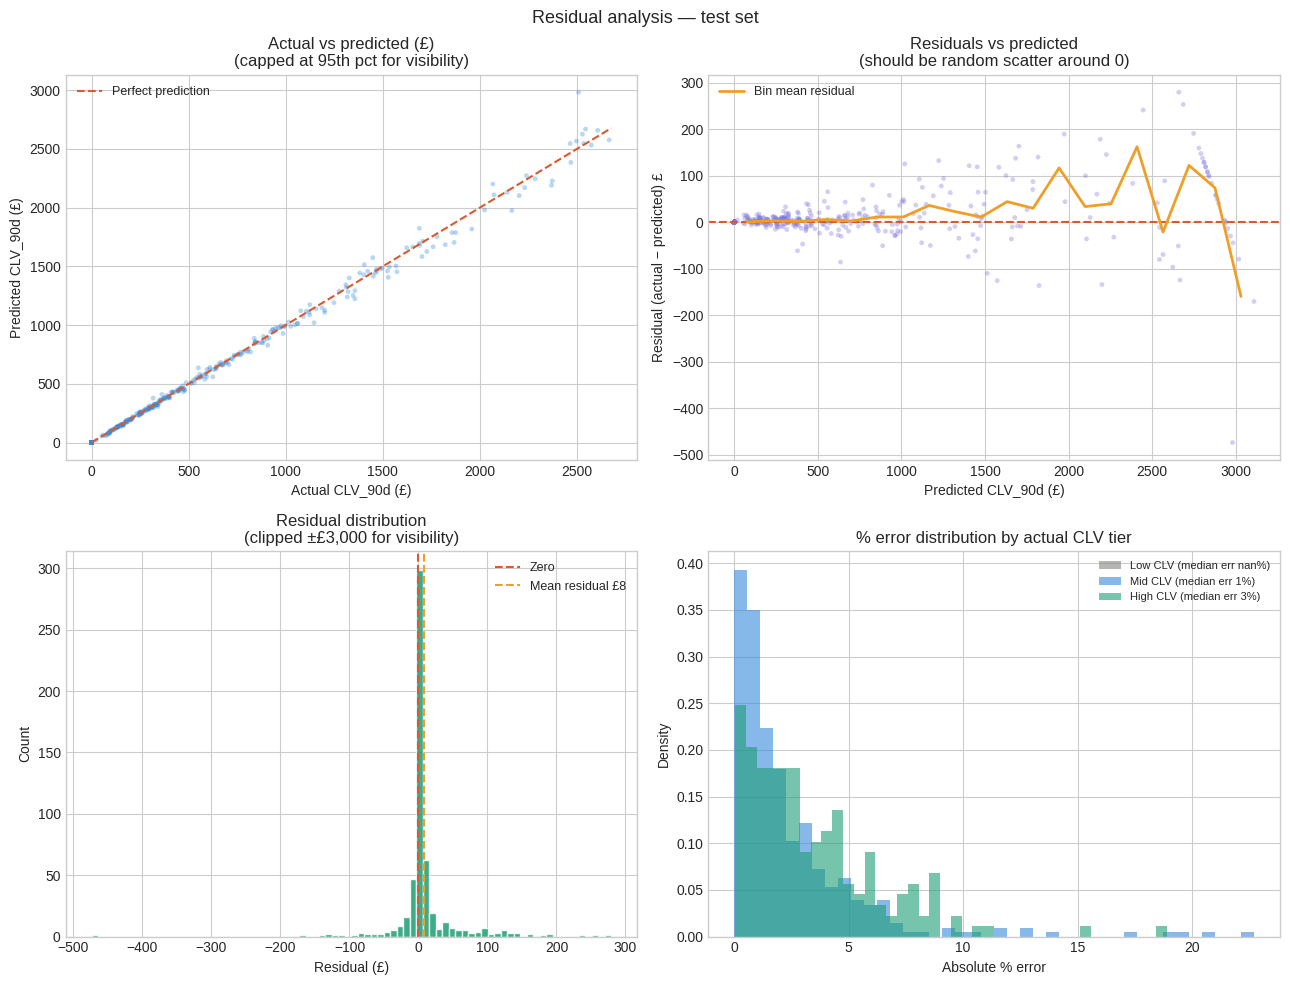


Mean residual      : £8.20  (close to 0 = unbiased)
Std  residual      : £46.69
% with |error|<30% : 100.0%


In [42]:
residuals = y_test_raw.values - test_pred_raw

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Residual analysis — test set", fontsize=13, fontweight="500")

# Plot 1 — actual vs predicted
ax = axes[0, 0]
cap = np.percentile(y_test_raw, 95)
mask = y_test_raw <= cap
ax.scatter(y_test_raw[mask], test_pred_raw[mask],
           alpha=0.35, color=PALETTE["blue"], s=12, edgecolors="none")
ax.plot([0, cap], [0, cap], color=PALETTE["coral"],
        linewidth=1.5, linestyle="--", label="Perfect prediction")
ax.set_title("Actual vs predicted (£)\n(capped at 95th pct for visibility)")
ax.set_xlabel("Actual CLV_90d (£)")
ax.set_ylabel("Predicted CLV_90d (£)")
ax.legend(fontsize=9)

# Plot 2 — residuals vs predicted
ax = axes[0, 1]
ax.scatter(test_pred_raw, residuals,
           alpha=0.35, color=PALETTE["purple"], s=12, edgecolors="none")
ax.axhline(0, color=PALETTE["coral"], linewidth=1.5, linestyle="--")
ax.set_title("Residuals vs predicted\n(should be random scatter around 0)")
ax.set_xlabel("Predicted CLV_90d (£)")
ax.set_ylabel("Residual (actual − predicted) £")

# add a loess-style smoothed line
from scipy.stats import binned_statistic
bin_means, bin_edges, _ = binned_statistic(
    test_pred_raw, residuals, statistic="mean", bins=20
)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centres, bin_means, color=PALETTE["amber"],
        linewidth=2, label="Bin mean residual")
ax.legend(fontsize=9)

# Plot 3 — residual distribution
ax = axes[1, 0]
ax.hist(residuals.clip(-3000, 3000), bins=80,
        color=PALETTE["green"], edgecolor="white", alpha=0.85)
ax.axvline(0,               color=PALETTE["coral"],
           linewidth=1.5, linestyle="--", label="Zero")
ax.axvline(residuals.mean(),color=PALETTE["amber"],
           linewidth=1.5, linestyle="--",
           label=f"Mean residual £{residuals.mean():.0f}")
ax.set_title("Residual distribution\n(clipped ±£3,000 for visibility)")
ax.set_xlabel("Residual (£)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# Plot 4 — % error by CLV tier (pre-tier)
ax = axes[1, 1]
pct_errors = np.abs(residuals / (y_test_raw + 1)) * 100
p33 = np.percentile(y_test_raw, 33)
p66 = np.percentile(y_test_raw, 66)
tier_labels = np.where(
    y_test_raw >= p66, "High CLV",
    np.where(y_test_raw >= p33, "Mid CLV", "Low CLV")
)
tier_df = pd.DataFrame({
    "tier"      : tier_labels,
    "pct_error" : pct_errors
})
tier_order  = ["Low CLV", "Mid CLV", "High CLV"]
tier_colors = [PALETTE["gray"], PALETTE["blue"], PALETTE["green"]]

for tier, color in zip(tier_order, tier_colors):
    data = tier_df[tier_df["tier"] == tier]["pct_error"].clip(upper=200)
    ax.hist(data, bins=40, alpha=0.6, color=color,
            label=f"{tier} (median err {data.median():.0f}%)",
            edgecolor="none", density=True)

ax.set_title("% error distribution by actual CLV tier")
ax.set_xlabel("Absolute % error")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nMean residual      : £{residuals.mean():.2f}  "
      f"(close to 0 = unbiased)")
print(f"Std  residual      : £{residuals.std():.2f}")
print(f"% with |error|<30% : "
      f"{(np.abs(residuals / (y_test_raw+1)) < 0.3).mean():.1%}")


In [43]:
# predict on ALL customers (train + test combined)
all_customers = pd.concat([train_df, test_df], ignore_index=True)
X_all = all_customers[FEATURE_COLS]

all_pred_log = final_model.predict(X_all)
all_pred_raw = np.expm1(all_pred_log)

all_customers["CLV_pred"]     = all_pred_raw
all_customers["CLV_pred_log"] = all_pred_log

# assign tiers
p33 = np.percentile(all_pred_raw, 33)
p66 = np.percentile(all_pred_raw, 66)

all_customers["CLV_Tier"] = np.where(
    all_pred_raw >= p66, "High CLV",
    np.where(all_pred_raw >= p33, "Mid CLV", "Low CLV")
)

print("CLV tier thresholds:")
print(f"  Low  CLV : predicted < £{p33:,.0f}")
print(f"  Mid  CLV : £{p33:,.0f} – £{p66:,.0f}")
print(f"  High CLV : predicted > £{p66:,.0f}")

tier_counts = all_customers["CLV_Tier"].value_counts()
print(f"\nTier distribution:")
for tier in ["High CLV", "Mid CLV", "Low CLV"]:
    n = tier_counts.get(tier, 0)
    print(f"  {tier} : {n:,} customers ({n/len(all_customers):.1%})")

CLV tier thresholds:
  Low  CLV : predicted < £0
  Mid  CLV : £0 – £209
  High CLV : predicted > £209

Tier distribution:
  High CLV : 937 customers (34.0%)
  Mid CLV : 908 customers (33.0%)
  Low CLV : 909 customers (33.0%)


In [44]:
TIER_ORDER  = ["High CLV", "Mid CLV", "Low CLV"]
TIER_COLORS = [PALETTE["green"], PALETTE["blue"], PALETTE["gray"]]

tier_summary = (
    all_customers.groupby("CLV_Tier")
    .agg(
        n_customers  = ("Customer ID",  "count"),
        avg_pred_clv = ("CLV_pred",     "mean"),
        total_pred   = ("CLV_pred",     "sum"),
        avg_recency  = ("Recency",      "mean"),
        avg_frequency= ("Frequency",    "mean"),
        avg_monetary = ("Monetary",     "mean"),
    )
    .reindex(TIER_ORDER)
    .round(1)
)

tier_summary["revenue_share_%"] = (
    tier_summary["total_pred"] /
    tier_summary["total_pred"].sum() * 100
).round(1)

print("\n" + "="*70)
print("  TIER BUSINESS SUMMARY")
print("="*70)
print(tier_summary.to_string())
print("="*70)

print(f"\nKey insight:")
high_rev_share = tier_summary.loc["High CLV","revenue_share_%"]
high_cust_share = (tier_summary.loc["High CLV","n_customers"] /
                   tier_summary["n_customers"].sum() * 100)
print(f"  Top {high_cust_share:.0f}% of customers (High CLV) drive "
      f"{high_rev_share:.0f}% of predicted 90-day revenue")


  TIER BUSINESS SUMMARY
          n_customers  avg_pred_clv  total_pred  avg_recency  avg_frequency  avg_monetary  revenue_share_%
CLV_Tier                                                                                                  
High CLV          937        871.00   816095.38        37.90           9.30       3469.20            95.80
Mid CLV           908         39.60    35942.30        72.90           4.20       1057.00             4.20
Low CLV           909         -0.00       -7.10        68.30           3.70       1152.90            -0.00

Key insight:
  Top 34% of customers (High CLV) drive 96% of predicted 90-day revenue


/tmp/ipykernel_253/519008815.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


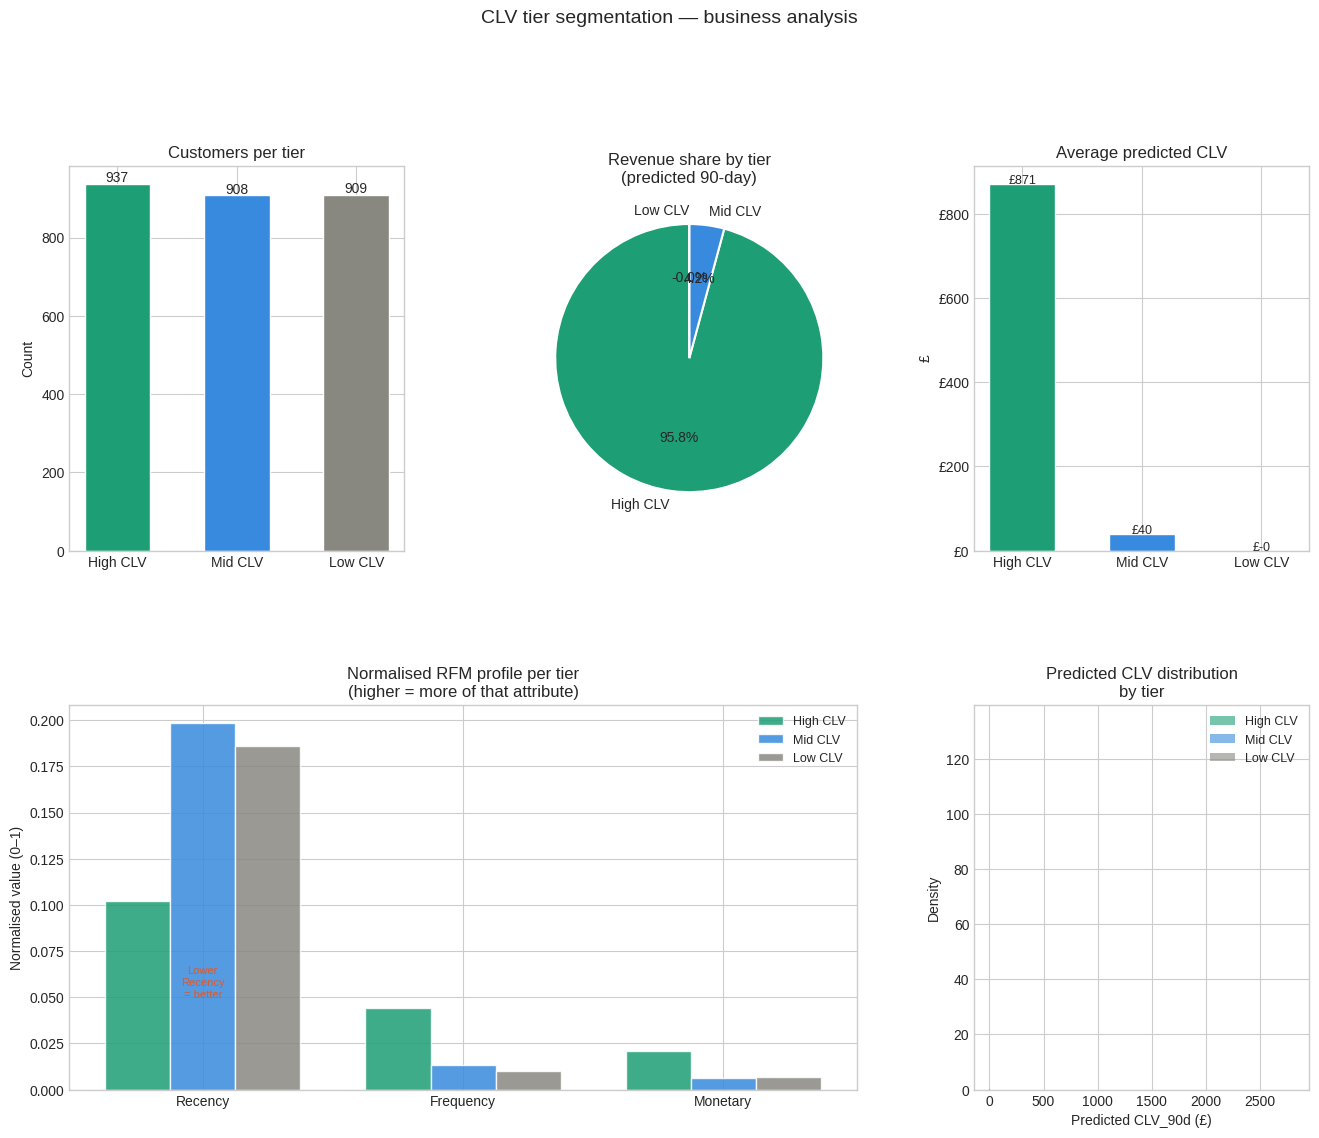

In [45]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
fig.suptitle("CLV tier segmentation — business analysis",
             fontsize=14, fontweight="500", y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1 — customer count per tier
ax1 = fig.add_subplot(gs[0, 0])
counts = [tier_summary.loc[t, "n_customers"] for t in TIER_ORDER]
bars   = ax1.bar(TIER_ORDER, counts, color=TIER_COLORS,
                 edgecolor="white", width=0.55)
ax1.set_title("Customers per tier")
ax1.set_ylabel("Count")
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{val:,}", ha="center", fontsize=10, fontweight="500")

# Plot 2 — revenue share pie
ax2 = fig.add_subplot(gs[0, 1])
rev_shares = [tier_summary.loc[t, "revenue_share_%"] for t in TIER_ORDER]
wedges, texts, autotexts = ax2.pie(
    rev_shares, labels=TIER_ORDER, colors=TIER_COLORS,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
ax2.set_title("Revenue share by tier\n(predicted 90-day)")

# Plot 3 — avg predicted CLV per tier
ax3 = fig.add_subplot(gs[0, 2])
avg_clvs = [tier_summary.loc[t, "avg_pred_clv"] for t in TIER_ORDER]
bars     = ax3.bar(TIER_ORDER, avg_clvs, color=TIER_COLORS,
                   edgecolor="white", width=0.55)
ax3.set_title("Average predicted CLV")
ax3.set_ylabel("£")
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)
for bar, val in zip(bars, avg_clvs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"£{val:,.0f}", ha="center", fontsize=9, fontweight="500")

# Plot 4 — RFM profile radar (simplified as grouped bar)
ax4 = fig.add_subplot(gs[1, :2])
rfm_features   = ["Recency", "Frequency", "Monetary"]
rfm_normalized = {}

for feat in rfm_features:
    col_vals = all_customers[feat]
    for tier in TIER_ORDER:
        tier_mean = all_customers[
            all_customers["CLV_Tier"] == tier
        ][feat].mean()
        key = f"{tier}_{feat}"
        # normalise 0-1 for comparability
        rfm_normalized[key] = (tier_mean - col_vals.min()) / \
                               (col_vals.max() - col_vals.min())

x    = np.arange(len(rfm_features))
w    = 0.25
for i, (tier, color) in enumerate(zip(TIER_ORDER, TIER_COLORS)):
    vals = [rfm_normalized[f"{tier}_{f}"] for f in rfm_features]
    bars = ax4.bar(x + i*w, vals, w, label=tier,
                   color=color, edgecolor="white", alpha=0.85)

ax4.set_title("Normalised RFM profile per tier\n"
              "(higher = more of that attribute)")
ax4.set_xticks(x + w)
ax4.set_xticklabels(rfm_features)
ax4.set_ylabel("Normalised value (0–1)")
ax4.legend(fontsize=9)

# Annotate recency direction
ax4.text(0 + w, 0.05,
         "Lower\nRecency\n= better",
         ha="center", fontsize=8, color=PALETTE["coral"])

# Plot 5 — predicted CLV distribution by tier
ax5 = fig.add_subplot(gs[1, 2])
for tier, color in zip(TIER_ORDER, TIER_COLORS):
    data = all_customers[all_customers["CLV_Tier"] == tier]["CLV_pred"]
    ax5.hist(data.clip(upper=data.quantile(0.95)),
             bins=40, alpha=0.6, color=color,
             label=tier, edgecolor="none", density=True)
ax5.set_title("Predicted CLV distribution\nby tier")
ax5.set_xlabel("Predicted CLV_90d (£)")
ax5.set_ylabel("Density")
ax5.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [46]:
print("\n" + "="*60)
print("  BUSINESS RECOMMENDATIONS BY CLV TIER")
print("="*60)

high = tier_summary.loc["High CLV"]
mid  = tier_summary.loc["Mid CLV"]
low  = tier_summary.loc["Low CLV"]

print(f"""
HIGH CLV  ({high['n_customers']:,.0f} customers — {high['revenue_share_%']:.0f}% of predicted revenue)
  Avg predicted 90-day value : £{high['avg_pred_clv']:,.0f}
  RFM profile : Recency {high['avg_recency']:.0f}d | {high['avg_frequency']:.1f} orders | £{high['avg_monetary']:,.0f} spend
  Action  : Priority retention. Assign dedicated account manager
             or loyalty programme. Cost of losing one = £{high['avg_pred_clv']:,.0f}.

MID CLV   ({mid['n_customers']:,.0f} customers — {mid['revenue_share_%']:.0f}% of predicted revenue)
  Avg predicted 90-day value : £{mid['avg_pred_clv']:,.0f}
  RFM profile : Recency {mid['avg_recency']:.0f}d | {mid['avg_frequency']:.1f} orders | £{mid['avg_monetary']:,.0f} spend
  Action  : Upsell and upgrade. Targeted vouchers to nudge
             toward High CLV behaviour. Highest ROI tier for
             marketing investment.

LOW CLV   ({low['n_customers']:,.0f} customers — {low['revenue_share_%']:.0f}% of predicted revenue)
  Avg predicted 90-day value : £{low['avg_pred_clv']:,.0f}
  RFM profile : Recency {low['avg_recency']:.0f}d | {low['avg_frequency']:.1f} orders | £{low['avg_monetary']:,.0f} spend
  Action  : Low-cost automated touchpoints only (email).
             Do not invest significant retention budget.
             Monitor for any movement toward Mid CLV.
""")


  BUSINESS RECOMMENDATIONS BY CLV TIER

HIGH CLV  (937 customers — 96% of predicted revenue)
  Avg predicted 90-day value : £871
  RFM profile : Recency 38d | 9.3 orders | £3,469 spend
  Action  : Priority retention. Assign dedicated account manager
             or loyalty programme. Cost of losing one = £871.

MID CLV   (908 customers — 4% of predicted revenue)
  Avg predicted 90-day value : £40
  RFM profile : Recency 73d | 4.2 orders | £1,057 spend
  Action  : Upsell and upgrade. Targeted vouchers to nudge
             toward High CLV behaviour. Highest ROI tier for
             marketing investment.

LOW CLV   (909 customers — -0% of predicted revenue)
  Avg predicted 90-day value : £-0
  RFM profile : Recency 68d | 3.7 orders | £1,153 spend
  Action  : Low-cost automated touchpoints only (email).
             Do not invest significant retention budget.
             Monitor for any movement toward Mid CLV.

